# Hello everyone! SBI is great!

In [10]:
import torch

from sbi.analysis import pairplot
from sbi.inference import SNPE, simulate_for_sbi
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)


In [50]:
num_dim = 50

def simulator(theta):
    # linear gaussian
    return theta + 1.0 + torch.randn_like(theta) * 0.1

prior = BoxUniform(low=-2 * torch.ones(num_dim), high=2 * torch.ones(num_dim))

In [51]:
# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(simulator, prior, prior_returns_numpy)

# Consistency check after making ready for sbi.
check_sbi_inputs(simulator, prior)

In [52]:
# This is how you sample from a distribution
n_simulations = 1000
thetas = prior.sample((n_simulations,))
thetas.shape

torch.Size([1000, 50])

In [54]:
xs = simulator(thetas)
xs.shape

torch.Size([1000, 50])

In [55]:
inference = SNPE(prior=prior)

In [56]:
# Adds the simulated data to your inference object
inference = inference.append_simulations(thetas, xs)

In [57]:
density_estimator = inference.train()

 Neural network successfully converged after 115 epochs.

In [58]:
posterior = inference.build_posterior(density_estimator)

print(posterior) # prints how the posterior was trained

Posterior conditional density p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [59]:
theta_true = prior.sample((1,))
# generate our observation
x_obs = simulator(theta_true)

In [60]:
theta_true, x_obs

(tensor([[-0.4958,  1.5079,  1.0466,  0.5924,  1.7958,  1.5096, -0.9341,  1.7241,
          -1.0166,  1.9733,  0.8402, -0.8559,  0.0663,  0.7064, -1.7852,  1.2999,
           0.3129, -1.0529, -1.4520,  1.5498,  0.5079, -0.4007,  0.6589, -1.8790,
          -0.5287, -0.3054, -0.6410,  0.6829,  1.8154,  0.2503,  1.6792, -1.7412,
          -1.6244,  0.8663,  0.4336, -1.8903, -1.8171,  1.7576,  0.0083,  1.4399,
           1.4006,  0.3591,  0.7041, -1.9250,  0.1766,  0.2422, -1.2644, -1.6101,
           0.7722,  0.9179]]),
 tensor([[ 4.0393e-01,  2.2698e+00,  1.9281e+00,  1.4814e+00,  2.9433e+00,
           2.5141e+00, -7.0887e-02,  2.8370e+00, -2.1213e-03,  2.9789e+00,
           1.8854e+00,  1.8317e-01,  9.8370e-01,  1.6298e+00, -6.4910e-01,
           2.3098e+00,  1.5092e+00, -7.5430e-02, -4.1349e-01,  2.4026e+00,
           1.5419e+00,  6.1317e-01,  1.6709e+00, -8.9225e-01,  2.6237e-01,
           7.7299e-01,  3.1964e-01,  1.7483e+00,  2.9468e+00,  9.9617e-01,
           2.8212e+00, -7.3

In [61]:
posterior_samples = posterior.sample((10000,), x=x_obs)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

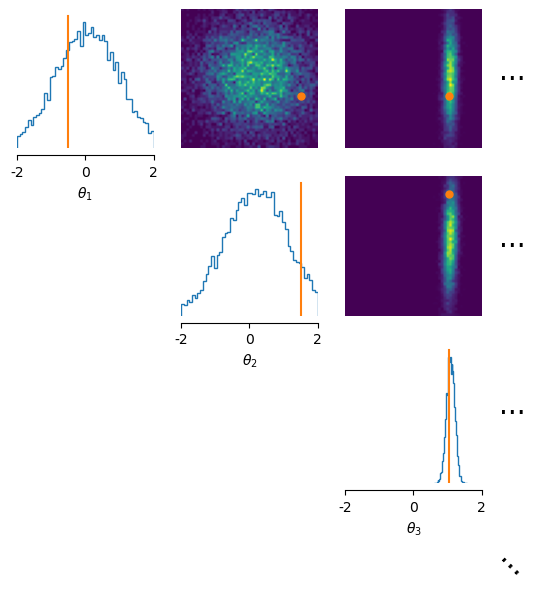

In [62]:
_ = pairplot(posterior_samples, points=theta_true, subset=[0,1,2] ,limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(6, 6),labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])

In [43]:
# This is the magic of amortization
# We make a different sample
theta_true_2 = prior.sample((1,))
x_obs_2 = simulator(theta_true_2)

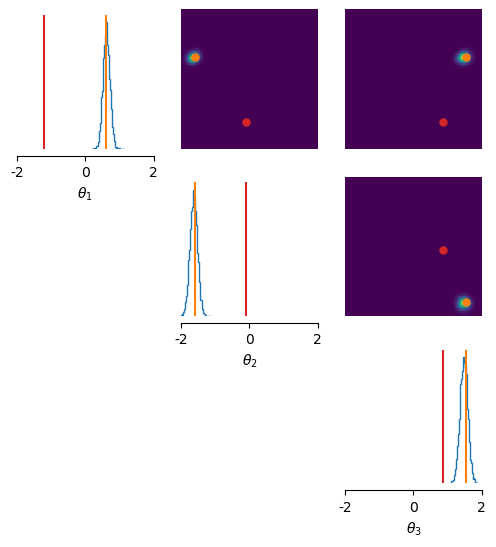

In [44]:
_ = pairplot(posterior_samples, points=[theta_true, theta_true_2], limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(6, 6),labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])

In [45]:
posterior.log_prob(theta_true, x=x_obs)

tensor([3.8376])

In [46]:
posterior.log_prob(theta_true_2, x=x_obs)

tensor([-98.0144])

In [48]:
posterior_samples_2 = posterior.sample((10000,), x=x_obs_2)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

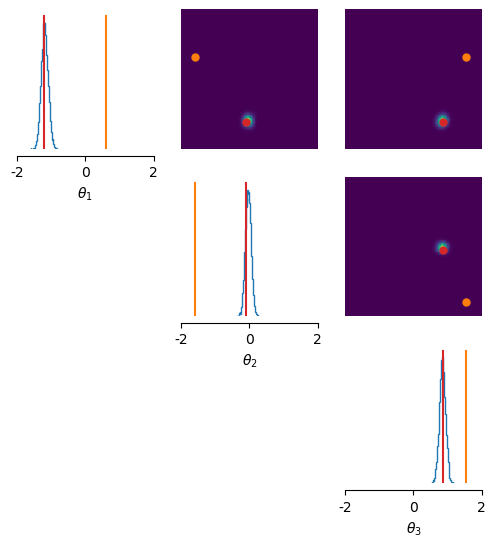

In [49]:
_ = pairplot(posterior_samples_2, points=[theta_true, theta_true_2], limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(6, 6),labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])